Sample Data: deterministic but small to help with the POC

# Setup

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
  
dataset = pd.read_csv('csvs/case_rate_sample.csv')

# Exploratory Aata Analysis (EDA)

In [89]:
dataset.count()

description      10
cases            10
customers        10
customer_type    10
ratio            10
period           10
period_count     10
dtype: int64

In [4]:
dataset.head()

,case_rate_id,description,cases,customers,customer_type,ratio,period,period_count
0,1,High case rate for dentists,120,30,dentist,4.0,Day,1
1,2,Moderate case rate for dentists,80,40,dentist,2.0,Week,1
2,3,Low case rate for dentists,50,50,dentist,1.0,Month,1
3,4,High case rate for offices,200,20,office,10.0,Day,1
4,5,Moderate case rate for offices,150,30,office,5.0,Week,1


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_rate_id   10 non-null     int64  
 1   description    10 non-null     object 
 2   cases          10 non-null     int64  
 3   customers      10 non-null     int64  
 4   customer_type  10 non-null     object 
 5   ratio          10 non-null     float64
 6   period         10 non-null     object 
 7   period_count   10 non-null     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 768.0+ bytes


In [68]:
dataset.describe()

,description,cases,customers,customer_type,ratio,period,period_count
count,10.00000,10.000000,10.00000,10.000000,10.000000,10.000000,10.0
mean,4.50000,155.000000,34.00000,1.100000,6.150000,1.200000,1.0
std,3.02765,80.311892,11.97219,0.875595,5.802538,1.032796,0.0
min,0.00000,50.000000,15.00000,0.000000,1.000000,0.000000,1.0
25%,2.25000,100.000000,26.25000,0.250000,2.125000,0.250000,1.0
50%,4.50000,135.000000,35.00000,1.000000,4.500000,1.000000,1.0
75%,6.75000,200.000000,40.00000,2.000000,8.750000,2.000000,1.0
max,9.00000,300.000000,50.00000,2.000000,20.000000,3.000000,1.0


In [9]:
dataset.isnull().any() 

case_rate_id     False
description      False
cases            False
customers        False
customer_type    False
ratio            False
period           False
period_count     False
dtype: bool

### Minor Data Processing to Analyze as Needed

In [40]:
dataset = dataset.drop(columns=['case_rate_id'])
# dataset["description"].fillna(dataset["description"].mode()[0],inplace = True) 


### Label Encoding
Transform textual data to numerical. 

In [17]:
label_encoder = LabelEncoder()
dataset['description'] = label_encoder.fit_transform(dataset['description'])
dataset['customer_type'] = label_encoder.fit_transform(dataset['customer_type'])
dataset['period'] = label_encoder.fit_transform(dataset['period'])

In [41]:
dataset.head()

,description,cases,customers,customer_type,ratio,period,period_count
0,0,120,30,0,4.0,0,1
1,6,80,40,0,2.0,2,1
2,3,50,50,0,1.0,1,1
3,1,200,20,1,10.0,0,1
4,7,150,30,1,5.0,2,1


### Heatmap

<Axes: >

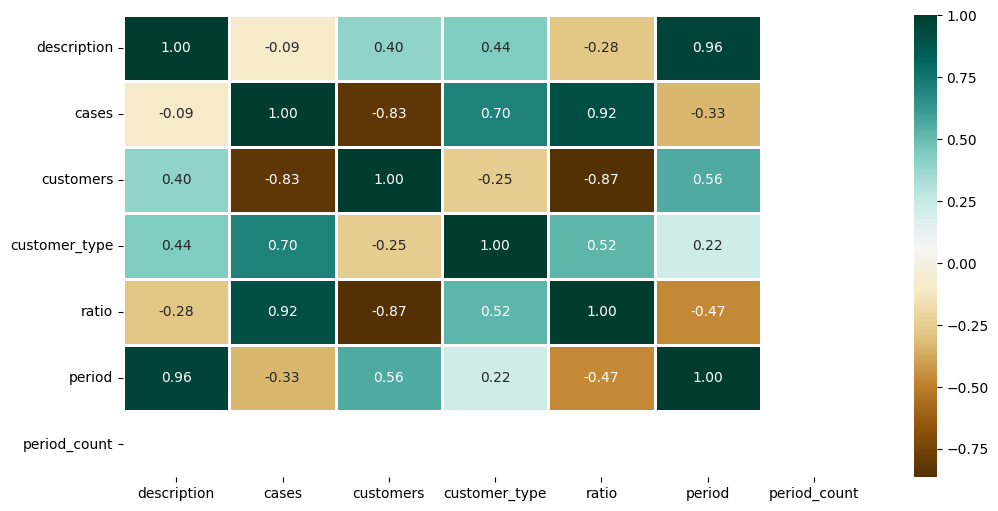

In [42]:
plt.figure(figsize=(12,6)) 

sns.heatmap(dataset.corr(), 
			cmap='BrBG', 
			fmt='.2f', 
			linewidths=2, 
			annot=True)


In [20]:
dataset.head()

,case_rate_id,description,cases,customers,customer_type,ratio,period,period_count
0,1,0,120,30,0,4.0,0,1
1,2,6,80,40,0,2.0,2,1
2,3,3,50,50,0,1.0,1,1
3,4,1,200,20,1,10.0,0,1
4,5,7,150,30,1,5.0,2,1


### Histogram

/var/folders/qx/d1p1qqy53056tw4dvkv0rlk40000gp/T/ipykernel_25531/1904010902.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[i])
/var/folders/qx/d1p1qqy53056tw4dvkv0rlk40000gp/T/ipykernel_25531/1904010902.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[i])
/var/folders/qx/

ValueError: num must be an integer with 1 <= num <= 4, not 5

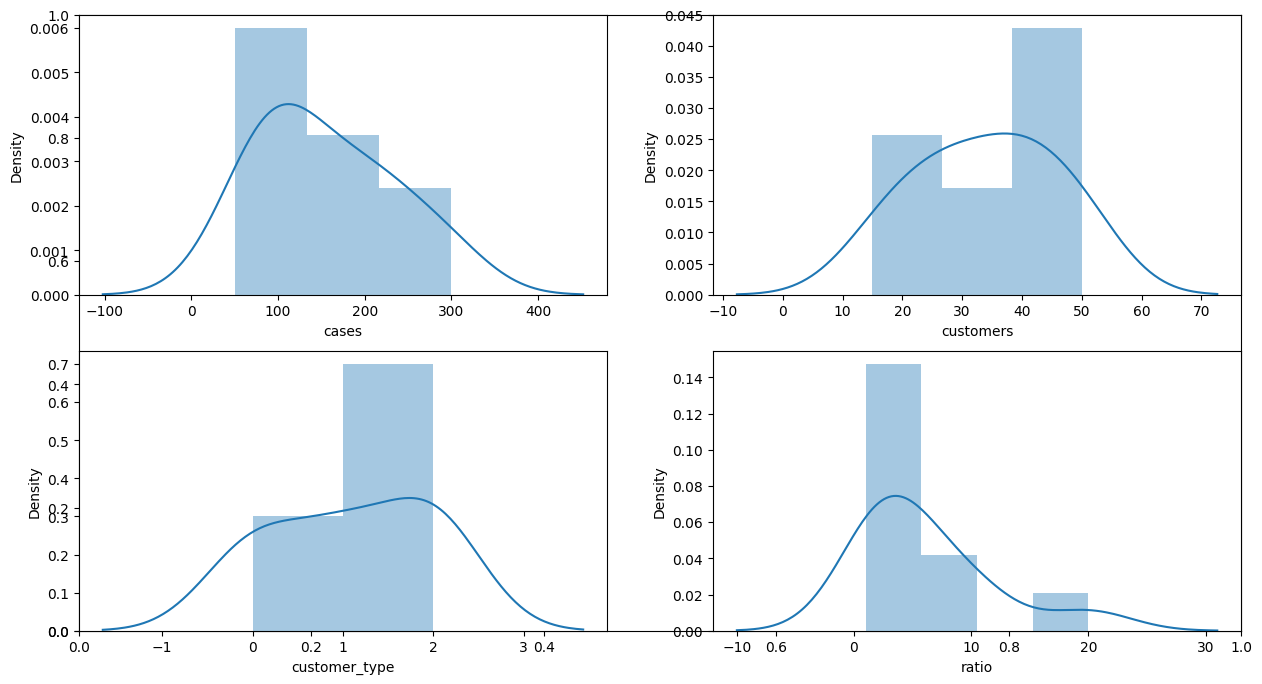

In [21]:
lis = ['cases', 'customers', 'customer_type', 'ratio', 'period_count', 'period'] 
plt.subplots(figsize=(15, 8)) 
index = 1

for i in lis: 
	plt.subplot(2, 2, index) 
	sns.distplot(dataset[i]) 
	index += 1


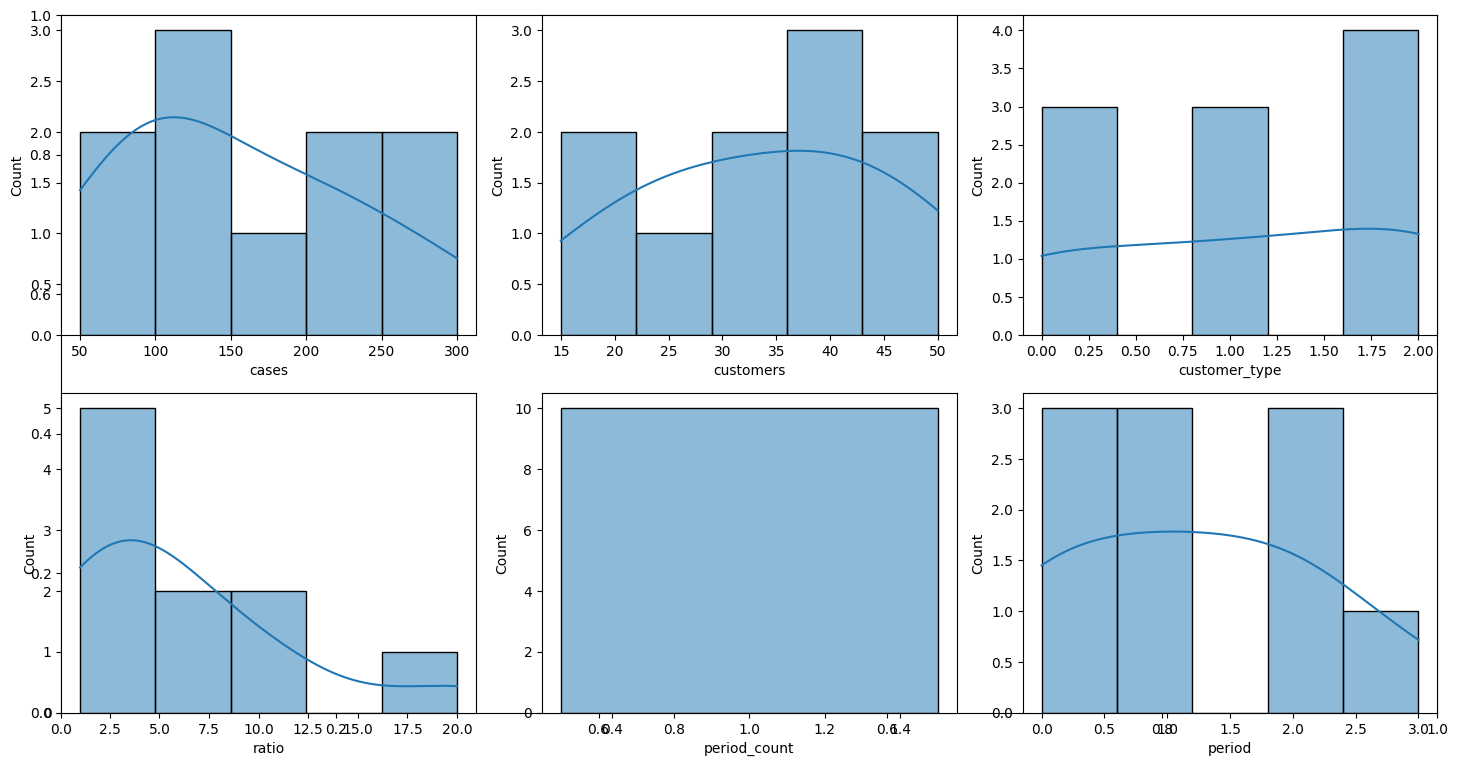

In [26]:
lis = ['cases', 'customers', 'customer_type', 'ratio', 'period_count', 'period'] 
plt.subplots(figsize=(15, 8)) 
index = 1

for i in lis: 
    plt.subplot(2, 3, index) 
    sns.histplot(dataset[i], kde=True) 
    index += 1

plt.tight_layout()
plt.show()

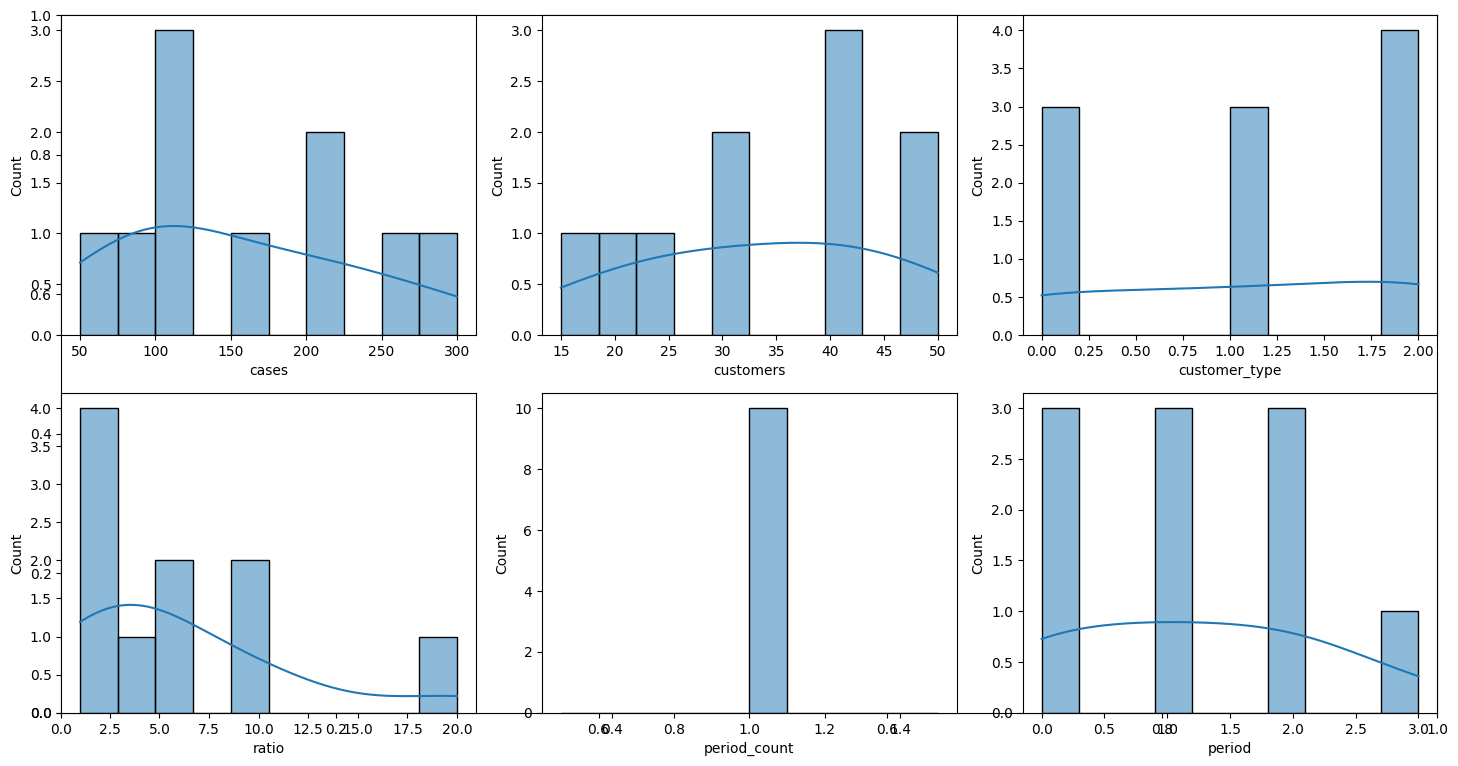

In [34]:
lis = ['cases', 'customers', 'customer_type', 'ratio', 'period_count', 'period'] 
plt.subplots(figsize=(15, 8)) 
index = 1

for i in lis: 
    plt.subplot(2, 3, index) 
    sns.histplot(dataset[i], bins=10, kde=True) 
    index += 1

plt.tight_layout()
plt.show()

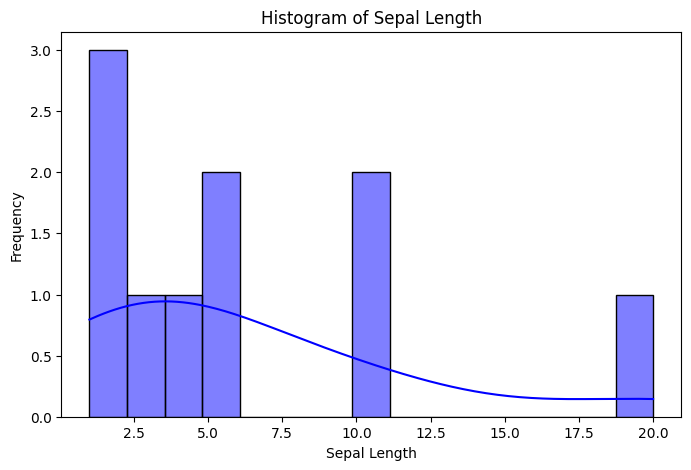

In [36]:
# Plot histogram for sepal_length
plt.figure(figsize=(8, 5))
sns.histplot(dataset['ratio'], bins=15, kde=True, color='blue')
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

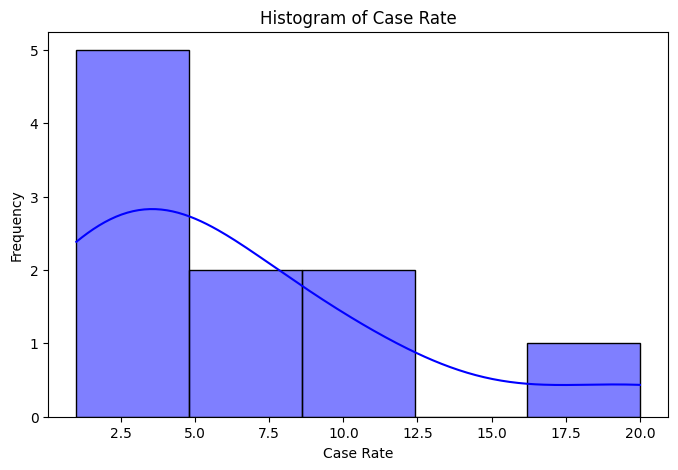

In [33]:
# Plot histogram for sepal_length
plt.figure(figsize=(8, 5))
sns.histplot(dataset['ratio'], bins=5, kde=True, color='blue')
plt.title('Histogram of Case Rate')
plt.xlabel('Case Rate')
plt.ylabel('Frequency')
plt.show()

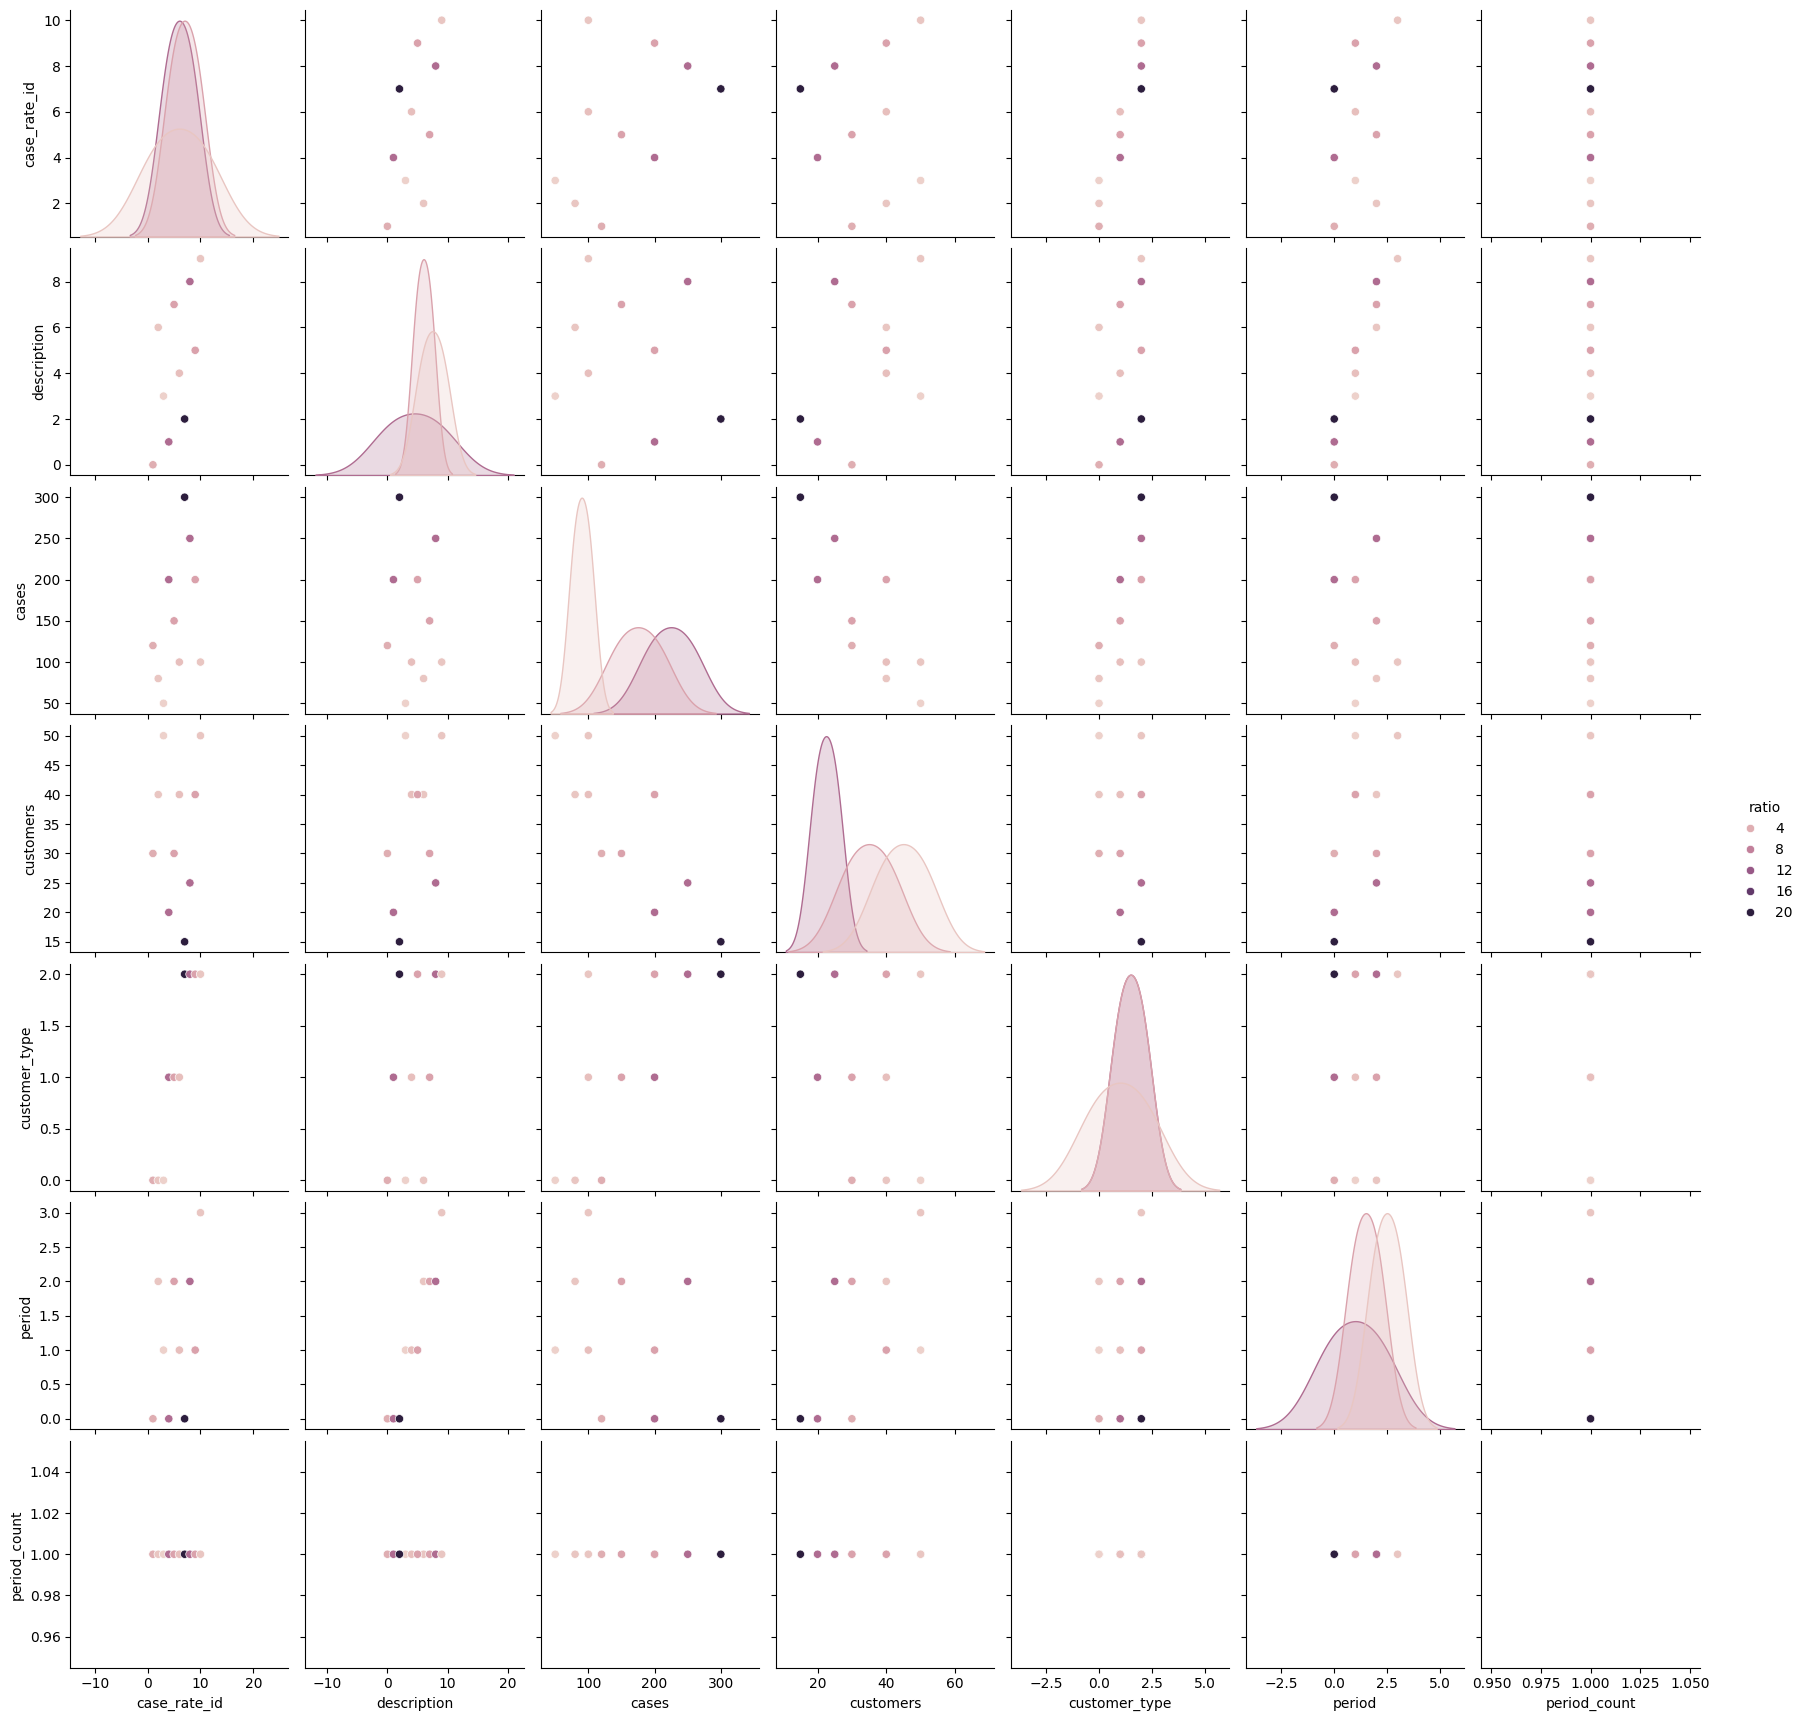

In [38]:
sns.pairplot(dataset, hue='ratio', diag_kind='kde')
plt.show()

# Data Preprocessing

In [39]:
dataset.isnull().any()

case_rate_id     False
description      False
cases            False
customers        False
customer_type    False
ratio            False
period           False
period_count     False
dtype: bool

### Pick Prediction Target

In [60]:
y = dataset.ratio
y

0     4.0
1     2.0
2     1.0
3    10.0
4     5.0
5     2.5
6    20.0
7    10.0
8     5.0
9     2.0
Name: ratio, dtype: float64

### Pick Features

In [66]:
features = ["cases", "customers","customer_type", "period", "period_count"]

X = dataset[features]
X

,cases,customers,customer_type,period,period_count
0,120,30,0,0,1
1,80,40,0,2,1
2,50,50,0,1,1
3,200,20,1,0,1
4,150,30,1,2,1
5,100,40,1,1,1
6,300,15,2,0,1
7,250,25,2,2,1
8,200,40,2,1,1
9,100,50,2,3,1


In [67]:
X.describe()

,cases,customers,customer_type,period,period_count
count,10.000000,10.00000,10.000000,10.000000,10.0
mean,155.000000,34.00000,1.100000,1.200000,1.0
std,80.311892,11.97219,0.875595,1.032796,0.0
min,50.000000,15.00000,0.000000,0.000000,1.0
25%,100.000000,26.25000,0.250000,0.250000,1.0
50%,135.000000,35.00000,1.000000,1.000000,1.0
75%,200.000000,40.00000,2.000000,2.000000,1.0
max,300.000000,50.00000,2.000000,3.000000,1.0


### Splitting Dependent and Independent Variables

### Via iloc (NEEDS WORk)

In [64]:
x_temp = dataset.iloc[:,0:4].values 
y_temp = dataset.iloc[:,13:14].values
x_temp

array([[  0, 120,  30,   0],
       [  6,  80,  40,   0],
       [  3,  50,  50,   0],
       [  1, 200,  20,   1],
       [  7, 150,  30,   1],
       [  4, 100,  40,   1],
       [  2, 300,  15,   2],
       [  8, 250,  25,   2],
       [  5, 200,  40,   2],
       [  9, 100,  50,   2]])

In [69]:
x_train, x_test, y_train, y_test = train_test_split(X,y, 
													test_size = 0.2, 
													random_state = 0)


In [70]:
x_train

,cases,customers,customer_type,period,period_count
4,150,30,1,2,1
9,100,50,2,3,1
1,80,40,0,2,1
6,300,15,2,0,1
7,250,25,2,2,1
3,200,20,1,0,1
0,120,30,0,0,1
5,100,40,1,1,1


In [71]:
x_test

,cases,customers,customer_type,period,period_count
2,50,50,0,1,1
8,200,40,2,1,1


In [72]:
x_train.describe()

,cases,customers,customer_type,period,period_count
count,8.000000,8.000000,8.000000,8.000000,8.0
mean,162.500000,31.250000,1.125000,1.250000,1.0
std,79.776473,11.572751,0.834523,1.164965,0.0
min,80.000000,15.000000,0.000000,0.000000,1.0
25%,100.000000,23.750000,0.750000,0.000000,1.0
50%,135.000000,30.000000,1.000000,1.500000,1.0
75%,212.500000,40.000000,2.000000,2.000000,1.0
max,300.000000,50.000000,2.000000,3.000000,1.0


### Feature Scaling

In [74]:
sc = StandardScaler() 
x_train = sc.fit_transform(x_train) 
x_test = sc.fit_transform(x_test)

In [76]:
x_train

array([[-0.1675063 , -0.11547005, -0.16012815,  0.6882472 ,  0.        ],
       [-0.83753151,  1.73205081,  1.12089708,  1.60591014,  0.        ],
       [-1.1055416 ,  0.80829038, -1.44115338,  0.6882472 ,  0.        ],
       [ 1.84256933, -1.5011107 ,  1.12089708, -1.14707867,  0.        ],
       [ 1.17254412, -0.57735027,  1.12089708,  0.6882472 ,  0.        ],
       [ 0.50251891, -1.03923048, -0.16012815, -1.14707867,  0.        ],
       [-0.56952143, -0.11547005, -1.44115338, -1.14707867,  0.        ],
       [-0.83753151,  0.80829038, -0.16012815, -0.22941573,  0.        ]])

In [75]:
# x_train.describe()

AttributeError: 'numpy.ndarray' object has no attribute 'describe'

# Modeling

## Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=1)

# does this work?? 
model.fit(X, y)

DecisionTreeRegressor(random_state=1)

In [79]:
model = DecisionTreeRegressor(random_state=1)

model.fit(x_train, y_train)


DecisionTreeRegressor(random_state=1)

In [80]:
predictions = model.predict(x_test)
predictions

array([ 2.5, 10. ])

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_metric = mean_absolute_error(y_test, predictions)
mae_metric

3.25

## Multi-Algorithm 

May need more data to validate better.

In [88]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.linear_model import LogisticRegression 

from sklearn import metrics 

knn = KNeighborsClassifier(n_neighbors=3) 
rfc = RandomForestClassifier(n_estimators = 7, 
							criterion = 'entropy', 
							random_state =7) 
svc = SVC() 
lc = LogisticRegression() 

# making predictions on the training set 
for clf in (rfc, knn, svc,lc): 
	# clf.fit(x_train, y_train) 
	clf.fit(x_train, y_train.astype(int))
	y_pred = clf.predict(x_test) 
	print("Accuracy score of ",clf.__class__.__name__,"=", 
		100*metrics.accuracy_score(y_test, y_pred))


Accuracy score of  RandomForestClassifier = 0.0
Accuracy score of  KNeighborsClassifier = 0.0
Accuracy score of  SVC = 0.0
Accuracy score of  LogisticRegression = 0.0
